In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Definir las funciones de activación y entrenamiento
def step_function(x):
  return np.where(x>= 0,1,0)

#Función para hacer predicciones

def perceptron_predict(x,weights):
  return step_function(np.dot(weights[1:],x)+ weights[0])

In [ ]:
# Algoritmo del Perceptrón
def perceptron_train(X, y, learning_rate=0.1, epochs=10):
    # Inicializar los pesos (uno más para el bias)
    weights = np.random.rand(X.shape[1] + 1)#np.zeros(X.shape[1] + 1)
    #vector de error
    errors = []
    # Entrenamiento
    for _ in range(epochs):
        total_error = 0
        for xi, target in zip(X, y):
            # Calcular la salida (predicción)
            output = perceptron_predict(xi,weights)#step_function(np.dot(xi, weights[1:]) + weights[0])
            # Calcular error absoluto
            error = target - output
            total_error += abs(error)
            # Actualizar los pesos
            update = learning_rate * (target - output)
            weights[1:] += update * xi
            weights[0] += update
        errors.append(total_error)
    return weights,errors


Pesos entrenados: [-0.46077701  0.26280797  0.21211085]


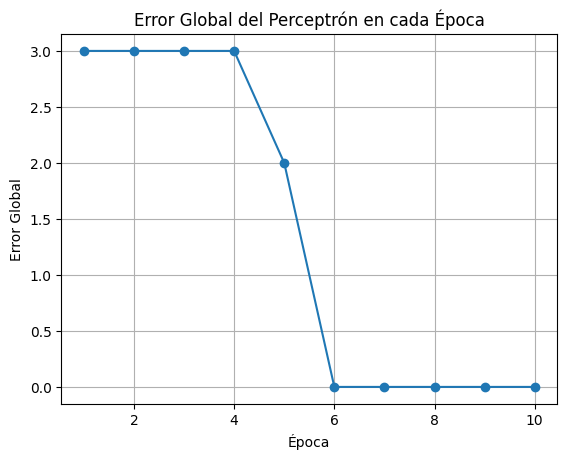

In [ ]:

# Preparar los datos de entrada y salida
# Datos de entrada para la compuerta AND
X = np.array([[0, 0],
              [0, 1],
              [1, 0],
              [1, 1]])

# Salidas esperadas para la compuerta AND
y = np.array([0, 0, 0, 1])
# Salidas esperadas para la compuerta OR
#y = np.array([0, 1, 1, 1])

# Entrenar el perceptrón
weights,errors = perceptron_train(X, y, learning_rate=0.1, epochs=10)
print("Pesos entrenados:", weights)

# Graficar el error global en cada época
plt.figure(1)
plt.plot(range(1, len(errors) + 1), errors, marker='o')
plt.xlabel('Época')
plt.ylabel('Error Global')
plt.title('Error Global del Perceptrón en cada Época')
plt.grid(True)






Entrada: [0 0], Salida predicha: 0
Entrada: [0 1], Salida predicha: 0
Entrada: [1 0], Salida predicha: 0
Entrada: [1 1], Salida predicha: 1


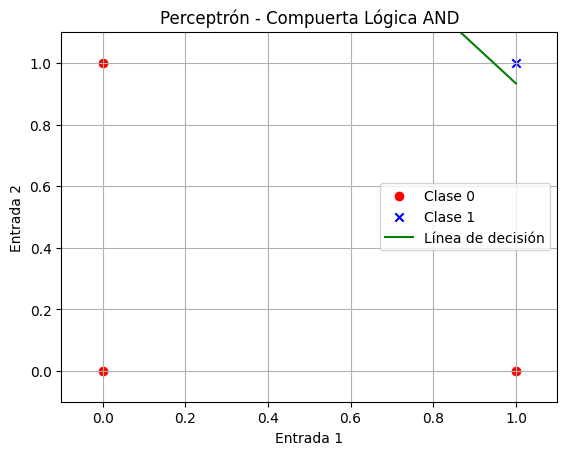

In [ ]:

# Probar el perceptrón con los datos de entrada
for xi in X:
    prediction = perceptron_predict(xi, weights)
    print(f"Entrada: {xi}, Salida predicha: {prediction}")

plt.figure(2)
# Graficar los puntos de datos
for i, xi in enumerate(X):
    if y[i] == 0:
        plt.scatter(xi[0], xi[1], color='red', marker='o', label='Clase 0' if i == 0 else "")
    else:
        plt.scatter(xi[0], xi[1], color='blue', marker='x', label='Clase 1' if i == 3 else "")

# Definir la línea de decisión
x_values = np.array([0, 1])
y_values = -(weights[1] * x_values + weights[0]) / weights[2]



# Graficar la línea de decisión

plt.plot(x_values, y_values, label='Línea de decisión', color='green')

# Configuraciones de la gráfica
plt.xlabel('Entrada 1')
plt.ylabel('Entrada 2')
plt.legend()
plt.title('Perceptrón - Compuerta Lógica AND')
plt.grid(True)
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)

# Mostrar la gráfica
plt.show()